<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Planulae_CellCount.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Styling & Setup
Imports the required data science packages and sets the visual fingerprint (fonts, colors, and line weights) so the final plot perfectly matches previous  figures.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 20,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "svg.fonttype": "none" # Protects text vectors for journal export
})
sns.set_theme(style="white", font="serif")

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
global_box_width = 0.6
global_fig_size = (6, 8)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6

# Centralized Asterisk & Significance Settings
global_asterisk_size = 12
global_asterisk_weight = 'bold'

# Added for significance mapping
def get_significance_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.005:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

# Added for cleaner look
global_y_nbins = 3
global_edgecolor = 'black'
global_line_width = 1.5

print(f"Global styling initialized. Significance mapping (p < 0.05: *, 0.005: **, 0.001: ***) added.")

Global styling initialized. Significance mapping (p < 0.05: *, 0.005: **, 0.001: ***) added.


## Block 2: Load Data & Convert Metrics (Cell/Planula + Cell/Volume)
This block loads the CSV, handles the spelling of your columns, and performs the mathematical normalizations. Note: I added an EXTRACTION_VOL_ML variable. If you crushed your planulae in 1 mL of seawater/preservative, leave it as 1.0. If you used 500 µL, change it to 0.5.

In [33]:
# 2. Load Data
filename = 'Algae_cell_count_16042026.csv'
df = pd.read_csv(filename)
df.columns = df.columns.str.strip() # Clean hidden spaces

# 2.5 Convert to cell/planula & cell/volume
EXTRACTION_VOL_ML = 1.0 # Change this if your slurry volume was not 1 mL

# Calculate Total Cells per Planula
# Formula: (Concentration per mL * Extraction Volume) / Number of Planulae in vial
df['Cells_per_Planula'] = (df['Conc (Cells/mL)'] * EXTRACTION_VOL_ML) / df['no of plaunlae per vile']

# Assign Morphotype Volumes
volume_map = {'HF': 0.3024, 'NF': 0.2698}
df['Volume_mm3'] = df['morph'].map(volume_map)

# Calculate Cell Density (Cells per mm³)
df['Cells_per_mm3'] = df['Cells_per_Planula'] / df['Volume_mm3']

# Drop any rows with missing calculations
df = df.dropna(subset=['Cells_per_mm3'])
print(f"✅ Data loaded and converted. Total viable samples: {len(df)}")

✅ Data loaded and converted. Total viable samples: 19


--- RAW COUNT DIVERGENCE ANALYSIS (PER SAMPLE) ---
⚠️ WARNING: Found 19 sample(s) with highly divergent internal counts (CV > 30%).
This indicates severe algae clumping, debris, or poor homogenization in these specific vials:

 Sample No morph  Grid_Mean  Grid_Std  Grid_CV(%)
       600    HF  144601.53 292337.62      202.17
       601    HF    6923.10  13994.49      202.14
       602    HF   97992.89 213316.93      217.69
       603    HF   16156.46  35160.15      217.62
       604    HF    5384.89  11720.36      217.65
       605    HF   10106.81  23452.21      232.04
       606    HF   65660.65 161254.55      245.59
       607    HF   26596.81  61716.37      232.04
       608    HF    8324.77  21511.11      258.40
       609    HF    9840.84  22835.05      232.04
       610    NF   27910.85  69928.60      250.54
       611    NF   68589.34 162405.18      236.78
       612    NF   23365.91  61565.58      263.48
       613    NF   12107.72  30329.67      250.50
       614    NF   7966

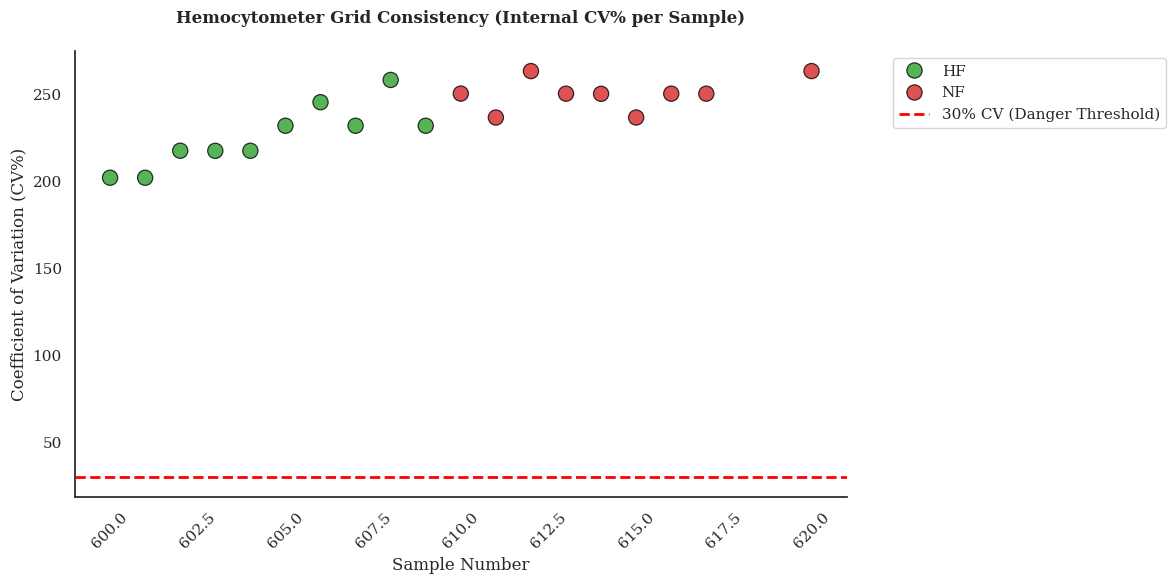

In [34]:
# Block 2.5: Internal Count Divergence Check (Per Sample)
print("--- RAW COUNT DIVERGENCE ANALYSIS (PER SAMPLE) ---")

# 1. Locate where the raw grid counts start in your CSV
# Based on your file, it starts at the column named 'Counts...'
counts_start_col = df.columns.get_loc('Counts...')

# 2. Extract just the grid counts for each row, ignoring empty columns
count_data = df.iloc[:, counts_start_col:].apply(pd.to_numeric, errors='coerce')

# 3. Calculate Mean, Standard Deviation, and CV% across the columns (axis=1) for each sample
df['Grid_Mean'] = count_data.mean(axis=1)
df['Grid_Std'] = count_data.std(axis=1)
df['Grid_CV(%)'] = (df['Grid_Std'] / df['Grid_Mean']) * 100

# Create a clean summary table
divergence_df = df[['Sample No', 'morph', 'Grid_Mean', 'Grid_Std', 'Grid_CV(%)']].copy()

# 4. Automated Warning System for Bad Samples
high_divergence = divergence_df[divergence_df['Grid_CV(%)'] > 30]

if not high_divergence.empty:
    print(f"⚠️ WARNING: Found {len(high_divergence)} sample(s) with highly divergent internal counts (CV > 30%).")
    print("This indicates severe algae clumping, debris, or poor homogenization in these specific vials:\n")
    print(high_divergence.round(2).to_string(index=False))
    print("\n-> This strongly justifies using the IQR Outlier removal in Block 3.")
else:
    print("✅ All samples show excellent internal counting consistency (CV < 30%).\n")

print("-" * 60)

# 5. Visualizing the Sample Quality
plt.figure(figsize=(12, 6))

# Plot CV% per sample
# FIXED: Changed morph_palette to variant_colors and added hue parameter
sns.scatterplot(data=divergence_df, x='Sample No', y='Grid_CV(%)',
                hue='morph', palette=variant_colors, s=120, edgecolor='black', alpha=0.8)

# Add a 'Danger Zone' threshold line at 30% CV
plt.axhline(30, color='red', linestyle='--', linewidth=2, label='30% CV (Danger Threshold)')

# Formatting the plot
plt.title("Hemocytometer Grid Consistency (Internal CV% per Sample)", weight='bold')
plt.ylabel("Coefficient of Variation (CV%)")
plt.xlabel("Sample Number")
plt.xticks(rotation=45) # Rotate sample numbers if they get crowded
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()

plt.tight_layout()
plt.show()

In [35]:
# --- TIER 1: TECHNICAL OUTLIER REMOVAL (PER SAMPLE) ---
print("--- TIER 1: TECHNICAL QC REPORT (GRID CLUMPING) ---")
counts_start_col = df.columns.get_loc('Counts...')
count_data = df.iloc[:, counts_start_col:]

clean_means = []
grids_dropped = []

# Iterate through every sample (row)
for idx, row in count_data.iterrows():
    # Extract only valid numbers, drop empty columns
    grids = pd.to_numeric(row, errors='coerce').dropna()

    # If a sample has at least 4 grid counts, we can perform IQR
    if len(grids) >= 4:
        Q1 = np.percentile(grids, 25)
        Q3 = np.percentile(grids, 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Filter the grids for this specific sample
        clean_grids = grids[(grids >= lower) & (grids <= upper)]
        clean_means.append(clean_grids.mean())
        grids_dropped.append(len(grids) - len(clean_grids))
    else:
        # Not enough grids to do IQR reliably, just take the mean
        clean_means.append(grids.mean())
        grids_dropped.append(0)

df['Clean_Grid_Mean'] = clean_means
df['Clumps_Dropped'] = grids_dropped

print(f"Total Technical Clumps (Grids) Dropped across all samples: {sum(grids_dropped)}")
# Show samples where grids were heavily manipulated
highly_cleaned = df[df['Clumps_Dropped'] > 0]
if not highly_cleaned.empty:
    print("\nSamples requiring grid cleanup:")
    print(highly_cleaned[['Sample No', 'morph', 'Average', 'Clean_Grid_Mean', 'Clumps_Dropped']])

--- TIER 1: TECHNICAL QC REPORT (GRID CLUMPING) ---
Total Technical Clumps (Grids) Dropped across all samples: 30

Samples requiring grid cleanup:
    Sample No morph  Average  Clean_Grid_Mean  Clumps_Dropped
0         600    HF  23.5000     74692.846108               1
1         601    HF   2.2500      3597.670365               1
2         602    HF  18.2000     49361.881511               1
3         603    HF   9.0000      8157.952863               1
4         604    HF   2.0000      2733.320483               1
5         605    HF   6.3333      4994.588714               1
6         606    HF  45.7143     31655.170585               1
7         607    HF  16.6667     13109.189189               1
8         608    HF   6.3750       784.951906               3
9         609    HF   6.1667      4863.708081               1
10        610    NF  11.8571      7957.306774               2
11        611    NF  39.3333     32961.698353               1
12        612    NF  16.3750      2160.059963  

## Block 3: Recalculate Densities & Tier 2 Biological QC (Per Morph)
Now that we have a clump-free technical mean, we convert it to volumetric density and apply our standard group-wise outlier filter.

In [38]:
# --- RECALCULATE DENSITIES BASED ON CLEAN MEANS ---
# Standard Hemocytometer formula: Count x 10,000
df['Clean_Conc_Cells_mL'] = df['Clean_Grid_Mean'] * 10000

EXTRACTION_VOL_ML = 1.0 # Adjust if you didn't use 1 mL
df['Cells_per_Planula'] = (df['Clean_Conc_Cells_mL'] * EXTRACTION_VOL_ML) / df['no of plaunlae per vile']

volume_map = {'HF': 0.3024, 'NF': 0.2698}
df['Volume_mm3'] = df['morph'].map(volume_map)
df['Cells_per_mm3'] = df['Cells_per_Planula'] / df['Volume_mm3']

df = df.dropna(subset=['Cells_per_mm3'])

# --- TIER 2: BIOLOGICAL OUTLIER REMOVAL (PER MORPH) ---
print("\n--- TIER 2: BIOLOGICAL QC REPORT (POPULATION DENSITY) ---")
def remove_biological_outliers(data, group_col, val_col):
    outliers_list, clean_list = [], []
    for name, group in data.groupby(group_col):
        Q1, Q3 = group[val_col].quantile(0.25), group[val_col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

        outliers = group[(group[val_col] < lower) | (group[val_col] > upper)]
        clean = group[(group[val_col] >= lower) & (group[val_col] <= upper)]

        outliers_list.append(outliers)
        clean_list.append(clean)
    return pd.concat(clean_list), pd.concat(outliers_list)

df_clean, df_outliers = remove_biological_outliers(df, 'morph', 'Cells_per_mm3')

print(f"Total Biological Outliers Removed: {len(df_outliers)}")
if not df_outliers.empty:
    print(df_outliers[['Sample No', 'morph', 'Cells_per_mm3']])
print(f"Total Samples Remaining for Final Stats: {len(df_clean)}")


--- TIER 2: BIOLOGICAL QC REPORT (POPULATION DENSITY) ---
Total Biological Outliers Removed: 3
    Sample No morph  Cells_per_mm3
0         600    HF   2.470002e+09
2         602    HF   1.632337e+09
11        611    NF   4.072362e+08
Total Samples Remaining for Final Stats: 16


## Block 4 & 5: Normality Check & Automated Stats
This block evaluates both metrics (Cells_per_Planula and Cells_per_mm3), decides between a T-test or Mann-Whitney U based on normality, and prints a formatted statistical report.

In [39]:
# 4. Normality Test & 5. Auto Statistical Test
metrics_to_test = ['Cells_per_Planula', 'Cells_per_mm3']
morphs = df_clean['morph'].unique()

print("\n" + "="*45)
print(" 🔬 COMPREHENSIVE STATISTICAL REPORT ")
print("="*45)

for metric in metrics_to_test:
    print(f"\n➤ Analyzing: {metric}")
    print("-" * 45)

    normality_pass = True
    groups = []

    # Check Normality
    for morph in morphs:
        data = df_clean[df_clean['morph'] == morph][metric].dropna()
        groups.append(data)
        stat, p_shapiro = stats.shapiro(data)
        is_normal = p_shapiro > 0.05
        normality_pass = normality_pass and is_normal
        print(f"[{morph}] Normality (p={p_shapiro:.4f}) -> {'Normal ✅' if is_normal else 'NOT Normal ❌'}")

    # Run Automated Stats
    if len(groups) == 2:
        if normality_pass:
            stat, p_val = stats.ttest_ind(groups[0], groups[1])
            test_used = "Independent T-test"
        else:
            stat, p_val = stats.mannwhitneyu(groups[0], groups[1])
            test_used = "Mann-Whitney U Test"

        sig = "Significant ⭐" if p_val < 0.05 else "Not Significant (ns)"

        print(f"Test Used : {test_used}")
        print(f"P-Value   : {p_val:.5e} | {sig}")
        print(f"Mean HF   : {groups[0].mean():.2f}")
        print(f"Mean NF   : {groups[1].mean():.2f}")
print("="*45)


 🔬 COMPREHENSIVE STATISTICAL REPORT 

➤ Analyzing: Cells_per_Planula
---------------------------------------------
[HF] Normality (p=0.0052) -> NOT Normal ❌
[NF] Normality (p=0.3801) -> Normal ✅
Test Used : Mann-Whitney U Test
P-Value   : 8.78477e-01 | Not Significant (ns)
Mean HF   : 30442519.84
Mean NF   : 22757506.32

➤ Analyzing: Cells_per_mm3
---------------------------------------------
[HF] Normality (p=0.0052) -> NOT Normal ❌
[NF] Normality (p=0.3801) -> Normal ✅
Test Used : Mann-Whitney U Test
P-Value   : 8.78477e-01 | Not Significant (ns)
Mean HF   : 100669708.46
Mean NF   : 84349541.58


## Plotting

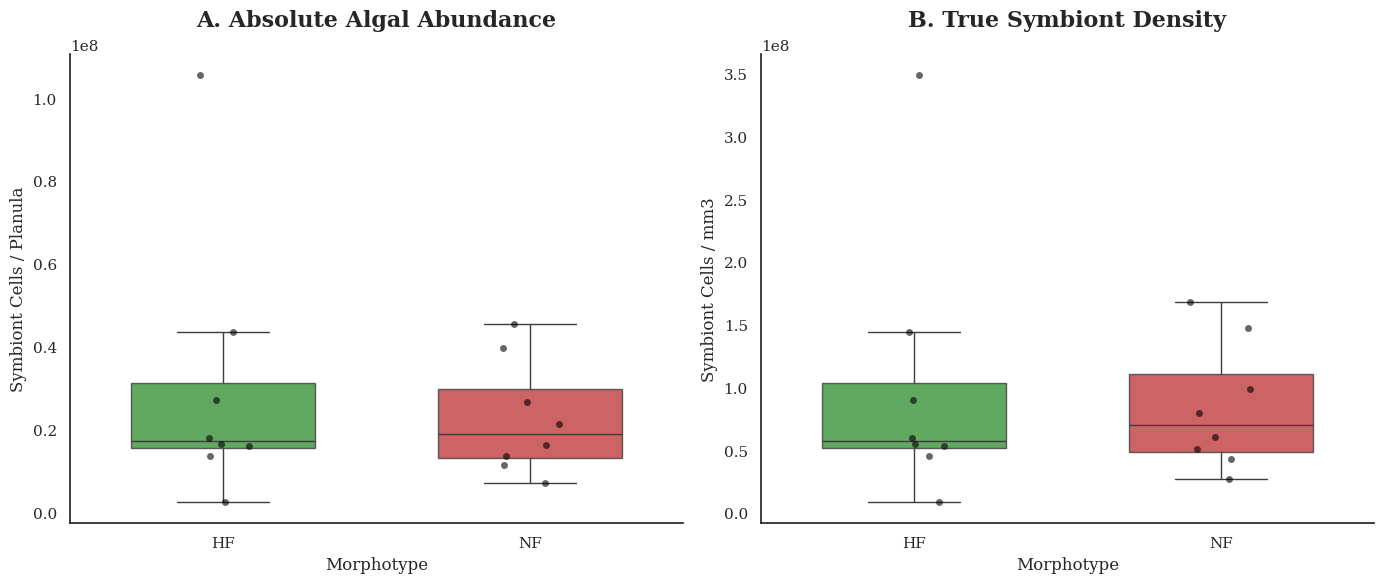

--- Descriptive Statistics ---


morph                              HF            NF
Cells_per_Planula count  8.000000e+00  8.000000e+00
                  mean   3.044252e+07  2.275751e+07
                  std    3.257092e+07  1.368155e+07
                  min    2.616506e+06  7.200200e+06
                  25%    1.557592e+07  1.314768e+07
                  50%    1.731849e+07  1.890258e+07
                  75%    3.131921e+07  2.992997e+07
                  max    1.055172e+08  4.539109e+07
Cells_per_mm3     count  8.000000e+00  8.000000e+00
                  mean   1.006697e+08  8.434954e+07
                  std    1.077081e+08  5.070996e+07
                  min    8.652468e+06  2.668718e+07
                  25%    5.150767e+07  4.873120e+07
                  50%    5.727014e+07  7.006146e+07
                  75%    1.035688e+08  1.109339e+08
                  max    3.489327e+08  1.682398e+08

In [45]:
# 6. Final Plotting (Normal Y-Axis)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prepare data for plotting
plot_df = df_clean.copy()

# Panel A: Cells per Planula (Absolute)
sns.boxplot(data=plot_df, x='morph', y='Cells_per_Planula', hue='morph', palette=variant_colors,
            ax=axes[0], showfliers=False, width=global_box_width, boxprops={'alpha': 0.8}, legend=False)
sns.stripplot(data=plot_df, x='morph', y='Cells_per_Planula', color='black',
              alpha=global_alpha, jitter=True, size=global_marker_size, ax=axes[0])
axes[0].set_title("A. Absolute Algal Abundance", fontsize=16, weight='bold')
axes[0].set_ylabel("Symbiont Cells / Planula")
axes[0].set_xlabel("Morphotype")

# Panel B: Cells per mm3 (Density)
sns.boxplot(data=plot_df, x='morph', y='Cells_per_mm3', hue='morph', palette=variant_colors,
            ax=axes[1], showfliers=False, width=global_box_width, boxprops={'alpha': 0.8}, legend=False)
sns.stripplot(data=plot_df, x='morph', y='Cells_per_mm3', color='black',
              alpha=global_alpha, jitter=True, size=global_marker_size, ax=axes[1])
axes[1].set_title("B. True Symbiont Density", fontsize=16, weight='bold')
axes[1].set_ylabel("Symbiont Cells / mm3")
axes[1].set_xlabel("Morphotype")

sns.despine(trim=False)
plt.tight_layout()
plt.show()

# Descriptive Statistics
print("--- Descriptive Statistics ---")
stats_summary = plot_df.groupby('morph')[['Cells_per_Planula', 'Cells_per_mm3']].describe().T
display(stats_summary.round(2))